<a href="https://colab.research.google.com/github/SitiMutmainah15/PCVK_GENAP_2026/blob/main/week5_244107020143.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [112]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [113]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import numpy as np
import matplotlib.pyplot as plt
import math
import glob
import os

<BarContainer object of 256 artists>

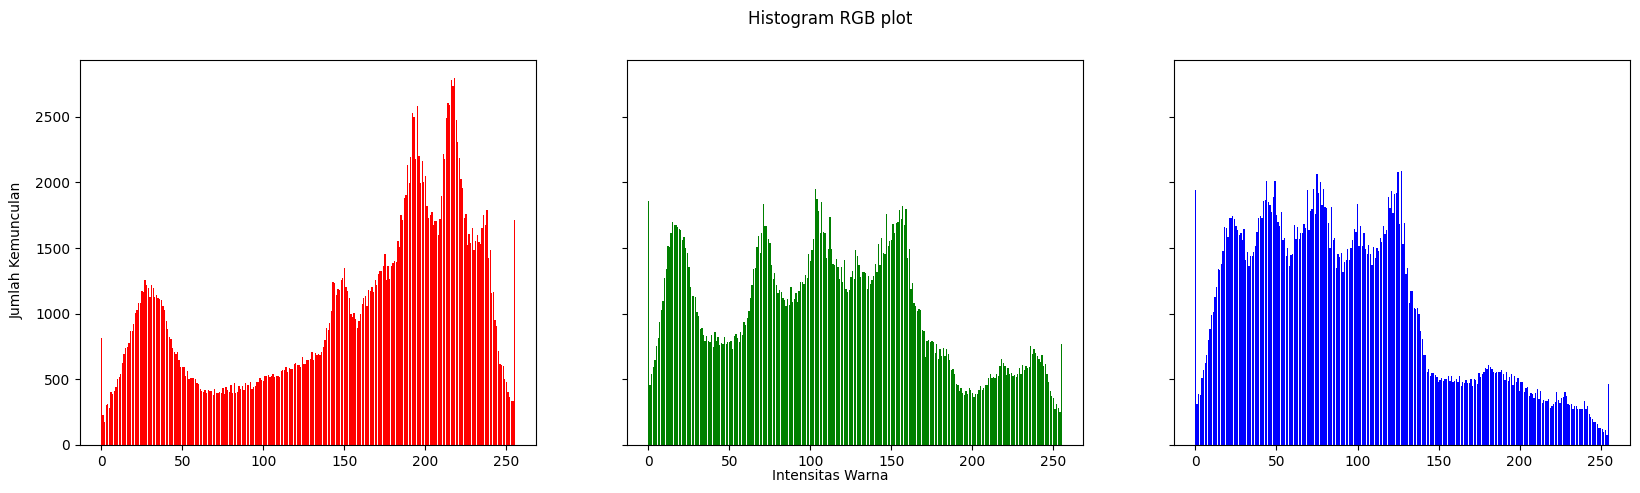

In [114]:
# membuat histogram
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

baca gambar,
amnbil ukuran gambar,
siapkan 256 tempat untuk RGB,
baca setiap pixel,
ambil nilai RGB,
tambah jumlah kemunculan,
tampil histogram,

In [115]:
!ls "/content/drive/MyDrive/PCVK/Images"

'2D Geometry Images'   kitten01.jpg	'Object Detection'
 anna.jpg	      'KTM lama.jpg'	 old_house.jpg
 corak.bmp	       ktp1.jpg		 peppers.jpg
 couple.tiff	       ktp.jpg		 peppers.tiff
 crayfish.jpg	       leaves.jpg	 prabowo.jpg
 crossword.jpg	       lena_gs_lc2.jpg	 romebeauty.jpg
 djawatan.jpg	       lena_gs_lc.jpg	 rose_pink.png
 facedet	       lena.jpg		 sailboat.tiff
 female.tiff	       lena_lc.jpg	 sudoku-original.jpg
 galaxy.jpg	       lily.jpg		 sunset.jpg
 gradient.jpg	       male.tiff	 tank.tiff
 haarcascades	       manalagi.jpg	 teeth.jpg
 houses.jpg	       mandrill2.tiff	 testlena2.jpg
 j.png		       mandrill.tiff	 testlena.jpg
 jungle.png	       noises		 wiki.jpg
 kids.jpeg	       noisy2.png


<BarContainer object of 256 artists>

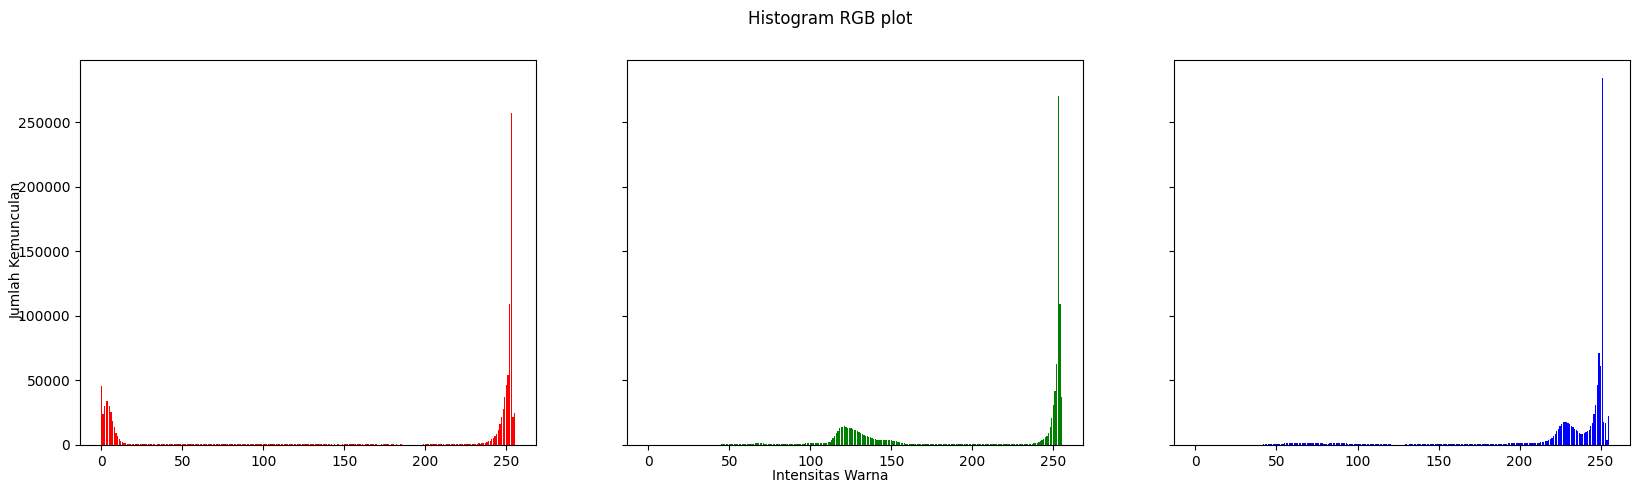

In [116]:
# membuat histogram
img = cv.imread('/content/KTM IIN2.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

grafik ktm tinggi di sebelah kanan karena banyak pixel RGB mendekati 255 (sebagian besar foto berwarna putih).

In [117]:
#soal no 1
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = img.shape

print("Ukuran citra:", img.shape)

Ukuran citra: (512, 512, 3)


In [118]:
#histogram manual
red_manual = [0] * 256
green_manual = [0] * 256
blue_manual = [0] * 256

for y in range(height):
    for x in range(width):
        red_manual[img[y][x][0]] += 1
        green_manual[img[y][x][1]] += 1
        blue_manual[img[y][x][2]] += 1

red_manual = np.array(red_manual)
green_manual = np.array(green_manual)
blue_manual = np.array(blue_manual)

In [119]:
#numpy histrogram
red_numpy, _ = np.histogram(img[:, :, 0], bins=256, range=(0, 256))
green_numpy, _ = np.histogram(img[:, :, 1], bins=256, range=(0, 256))
blue_numpy, _ = np.histogram(img[:, :, 2], bins=256, range=(0, 256))

In [120]:
#cv.calcHist
red_cv = cv.calcHist([img], [0], None, [256], [0, 256]).flatten()
green_cv = cv.calcHist([img], [1], None, [256], [0, 256]).flatten()
blue_cv = cv.calcHist([img], [2], None, [256], [0, 256]).flatten()

In [121]:
print("=== CHANNEL RED ===")
print("Manual vs NumPy  :", np.max(np.abs(red_manual - red_numpy)))
print("Manual vs OpenCV :", np.max(np.abs(red_manual - red_cv)))
print("NumPy vs OpenCV  :", np.max(np.abs(red_numpy - red_cv)))

print("\n=== CHANNEL GREEN ===")
print("Manual vs NumPy  :", np.max(np.abs(green_manual - green_numpy)))
print("Manual vs OpenCV :", np.max(np.abs(green_manual - green_cv)))
print("NumPy vs OpenCV  :", np.max(np.abs(green_numpy - green_cv)))

print("\n=== CHANNEL BLUE ===")
print("Manual vs NumPy  :", np.max(np.abs(blue_manual - blue_numpy)))
print("Manual vs OpenCV :", np.max(np.abs(blue_manual - blue_cv)))
print("NumPy vs OpenCV  :", np.max(np.abs(blue_numpy - blue_cv)))

=== CHANNEL RED ===
Manual vs NumPy  : 0
Manual vs OpenCV : 0.0
NumPy vs OpenCV  : 0.0

=== CHANNEL GREEN ===
Manual vs NumPy  : 0
Manual vs OpenCV : 0.0
NumPy vs OpenCV  : 0.0

=== CHANNEL BLUE ===
Manual vs NumPy  : 0
Manual vs OpenCV : 0.0
NumPy vs OpenCV  : 0.0


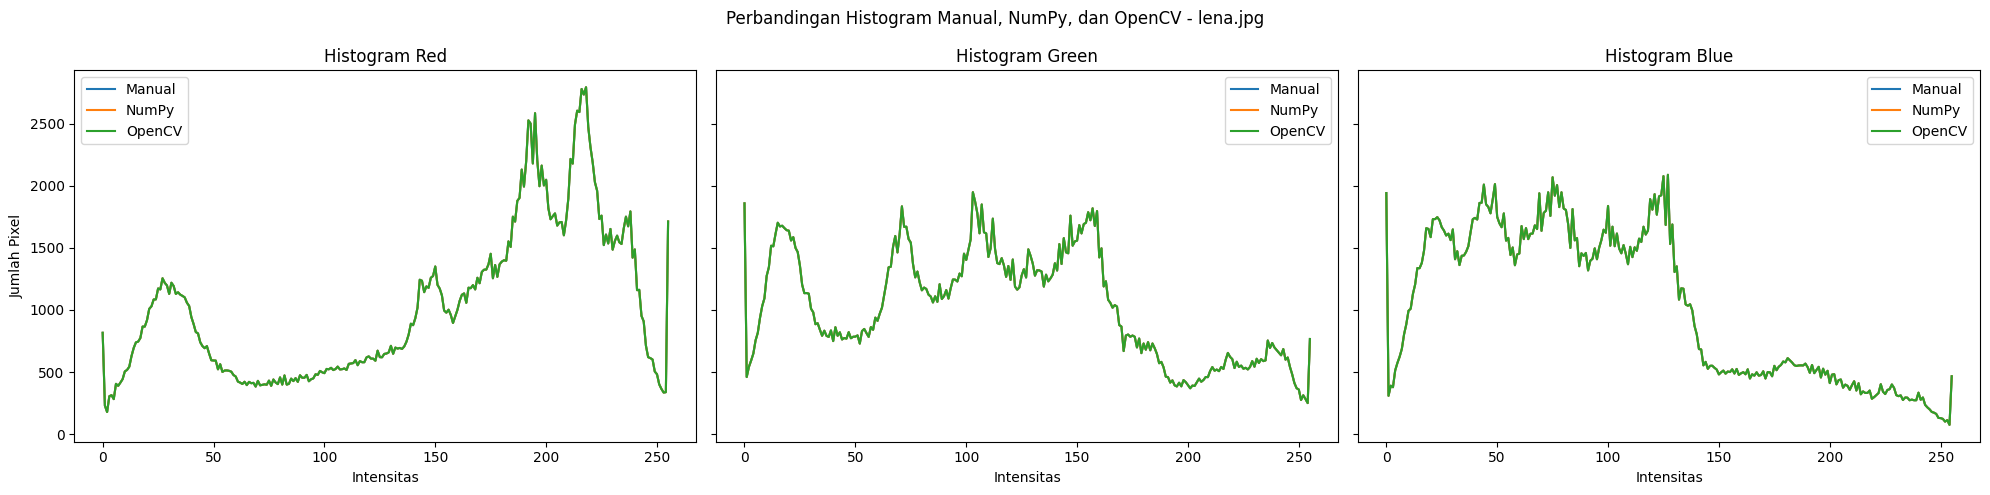

In [122]:
names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)

# RED
axs[0].plot(names, red_manual, label='Manual')
axs[0].plot(names, red_numpy, label='NumPy')
axs[0].plot(names, red_cv, label='OpenCV')
axs[0].set_title('Histogram Red')
axs[0].set_xlabel('Intensitas')
axs[0].set_ylabel('Jumlah Pixel')
axs[0].legend()

# GREEN
axs[1].plot(names, green_manual, label='Manual')
axs[1].plot(names, green_numpy, label='NumPy')
axs[1].plot(names, green_cv, label='OpenCV')
axs[1].set_title('Histogram Green')
axs[1].set_xlabel('Intensitas')
axs[1].legend()

# BLUE
axs[2].plot(names, blue_manual, label='Manual')
axs[2].plot(names, blue_numpy, label='NumPy')
axs[2].plot(names, blue_cv, label='OpenCV')
axs[2].set_title('Histogram Blue')
axs[2].set_xlabel('Intensitas')
axs[2].legend()

fig.suptitle('Perbandingan Histogram Manual, NumPy, dan OpenCV - lena.jpg')

plt.tight_layout()
plt.show()

disini muncul hanya 1 garis hijau karena ketiga histogrammenghasilkan nilai yang sama persis, sehingga garisnya menumpuk

In [123]:
img = cv.imread('/content/KTM IIN2.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = img.shape

print("Ukuran citra:", img.shape)

Ukuran citra: (828, 1301, 3)


In [124]:
#histogram manual
red_manual = [0] * 256
green_manual = [0] * 256
blue_manual = [0] * 256

for y in range(height):
    for x in range(width):
        red_manual[img[y][x][0]] += 1
        green_manual[img[y][x][1]] += 1
        blue_manual[img[y][x][2]] += 1

red_manual = np.array(red_manual)
green_manual = np.array(green_manual)
blue_manual = np.array(blue_manual)

In [125]:
#numpy histrogram
red_numpy, _ = np.histogram(img[:, :, 0], bins=256, range=(0, 256))
green_numpy, _ = np.histogram(img[:, :, 1], bins=256, range=(0, 256))
blue_numpy, _ = np.histogram(img[:, :, 2], bins=256, range=(0, 256))

In [126]:
#cv.calcHist
red_cv = cv.calcHist([img], [0], None, [256], [0, 256]).flatten()
green_cv = cv.calcHist([img], [1], None, [256], [0, 256]).flatten()
blue_cv = cv.calcHist([img], [2], None, [256], [0, 256]).flatten()

In [127]:
print("=== CHANNEL RED ===")
print("Manual vs NumPy  :", np.max(np.abs(red_manual - red_numpy)))
print("Manual vs OpenCV :", np.max(np.abs(red_manual - red_cv)))
print("NumPy vs OpenCV  :", np.max(np.abs(red_numpy - red_cv)))

print("\n=== CHANNEL GREEN ===")
print("Manual vs NumPy  :", np.max(np.abs(green_manual - green_numpy)))
print("Manual vs OpenCV :", np.max(np.abs(green_manual - green_cv)))
print("NumPy vs OpenCV  :", np.max(np.abs(green_numpy - green_cv)))

print("\n=== CHANNEL BLUE ===")
print("Manual vs NumPy  :", np.max(np.abs(blue_manual - blue_numpy)))
print("Manual vs OpenCV :", np.max(np.abs(blue_manual - blue_cv)))
print("NumPy vs OpenCV  :", np.max(np.abs(blue_numpy - blue_cv)))

=== CHANNEL RED ===
Manual vs NumPy  : 0
Manual vs OpenCV : 0.0
NumPy vs OpenCV  : 0.0

=== CHANNEL GREEN ===
Manual vs NumPy  : 0
Manual vs OpenCV : 0.0
NumPy vs OpenCV  : 0.0

=== CHANNEL BLUE ===
Manual vs NumPy  : 0
Manual vs OpenCV : 0.0
NumPy vs OpenCV  : 0.0


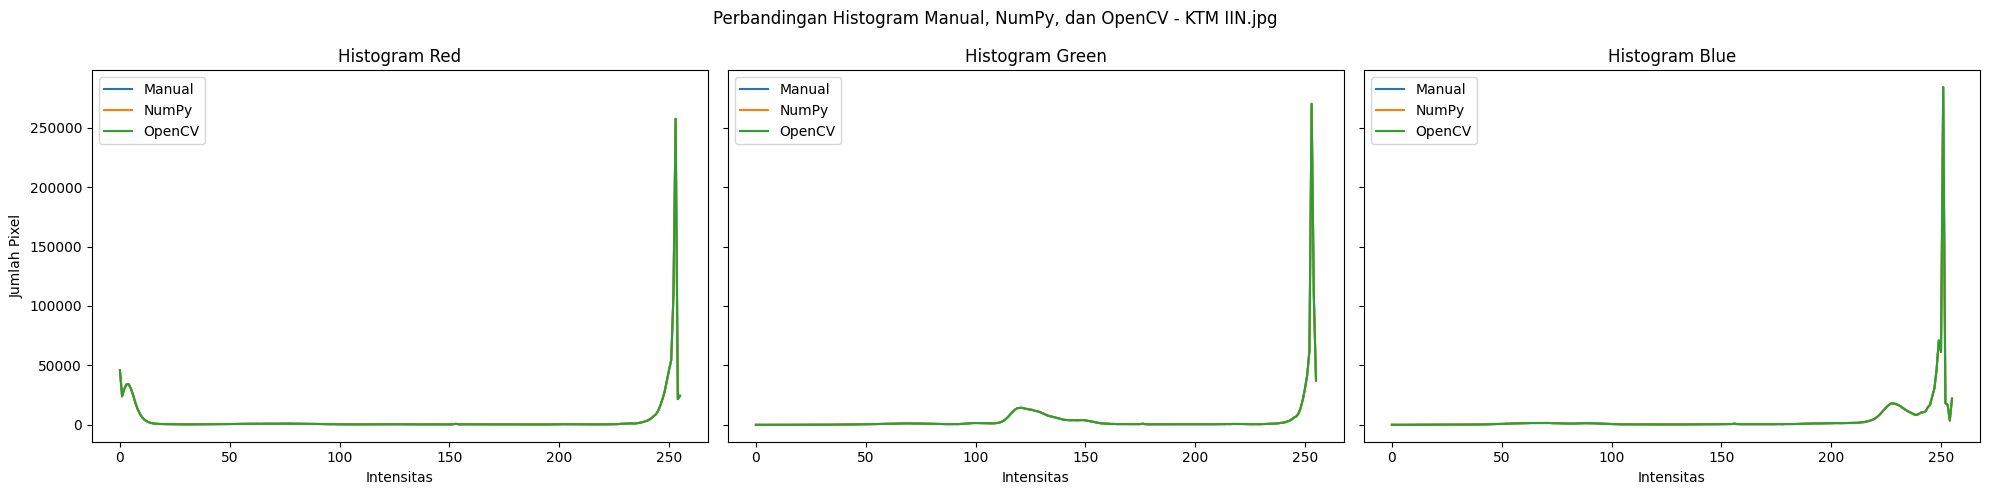

In [128]:
names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)

# RED
axs[0].plot(names, red_manual, label='Manual')
axs[0].plot(names, red_numpy, label='NumPy')
axs[0].plot(names, red_cv, label='OpenCV')
axs[0].set_title('Histogram Red')
axs[0].set_xlabel('Intensitas')
axs[0].set_ylabel('Jumlah Pixel')
axs[0].legend()

# GREEN
axs[1].plot(names, green_manual, label='Manual')
axs[1].plot(names, green_numpy, label='NumPy')
axs[1].plot(names, green_cv, label='OpenCV')
axs[1].set_title('Histogram Green')
axs[1].set_xlabel('Intensitas')
axs[1].legend()

# BLUE
axs[2].plot(names, blue_manual, label='Manual')
axs[2].plot(names, blue_numpy, label='NumPy')
axs[2].plot(names, blue_cv, label='OpenCV')
axs[2].set_title('Histogram Blue')
axs[2].set_xlabel('Intensitas')
axs[2].legend()

fig.suptitle('Perbandingan Histogram Manual, NumPy, dan OpenCV - KTM IIN.jpg')

plt.tight_layout()
plt.show()

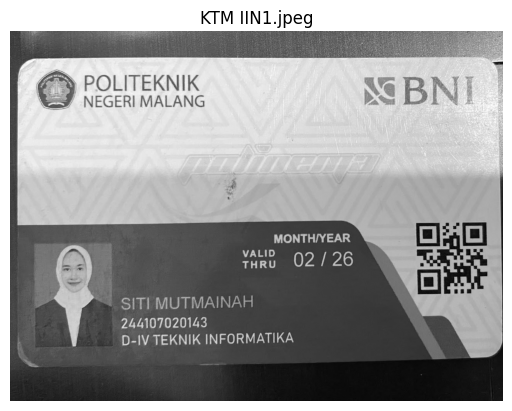

In [129]:
#soal no 2
img = cv.imread(
    '/content/KTM IIN1.jpeg',
    cv.IMREAD_GRAYSCALE
)

plt.imshow(img, cmap='gray')
plt.title('KTM IIN1.jpeg')
plt.axis('off')
plt.show()

In [130]:
hist, bins = np.histogram(
    img.flatten(),
    bins=256,
    range=(0, 256)
)

In [131]:
total_pixel = img.size

In [132]:
hist_normalized = hist / total_pixel

In [133]:
print(np.sum(hist_normalized))

1.0


In [134]:
cdf = np.cumsum(hist_normalized)

In [135]:
print(cdf[-1])

0.9999999999999999


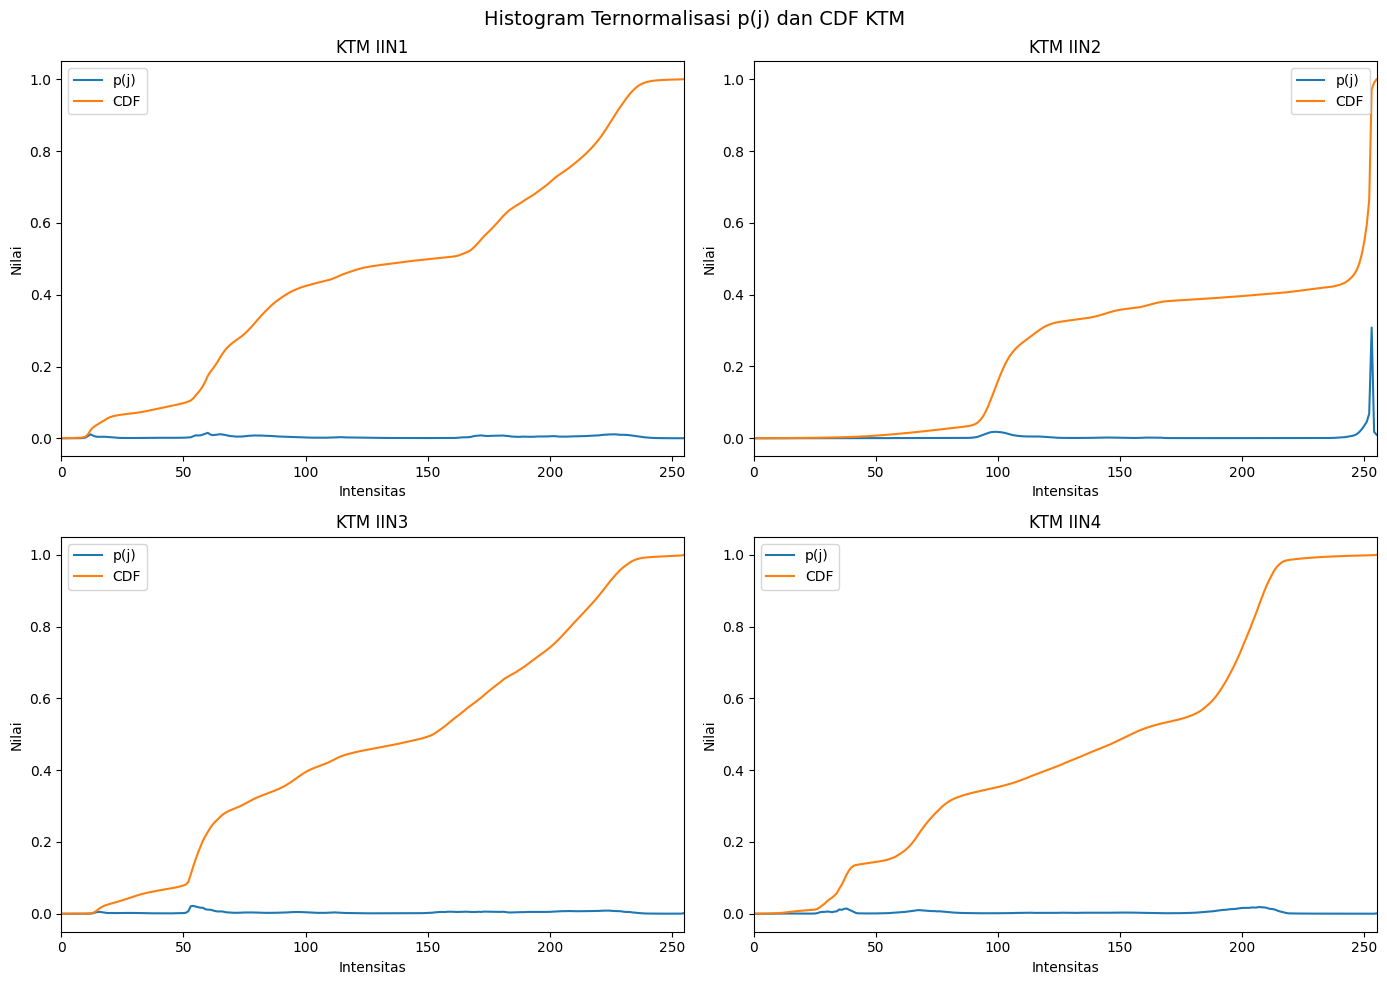

In [136]:
paths = [
    '/content/KTM IIN1.jpeg',
    '/content/KTM IIN2.jpeg',
    '/content/KTM IIN3.jpeg',
    '/content/KTM IIN4.jpeg'
]

names = [
    'KTM IIN1',
    'KTM IIN2',
    'KTM IIN3',
    'KTM IIN4'
]

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

for ax, path, name in zip(axs.flat, paths, names):

    # Membaca gambar dalam grayscale
    img = cv.imread(path, cv.IMREAD_GRAYSCALE)

    # Menghitung histogram
    hist, _ = np.histogram(
        img.flatten(),
        bins=256,
        range=(0, 256)
    )

    # Normalisasi histogram menjadi p(j)
    hist_normalized = hist / img.size

    # Menghitung CDF
    cdf = np.cumsum(hist_normalized)

    # Menampilkan p(j)
    ax.plot(
        np.arange(256),
        hist_normalized,
        label='p(j)'
    )

    # Menampilkan CDF
    ax.plot(
        np.arange(256),
        cdf,
        label='CDF'
    )

    ax.set_title(name)
    ax.set_xlabel('Intensitas')
    ax.set_ylabel('Nilai')
    ax.set_xlim(0, 255)
    ax.legend()

fig.suptitle(
    'Histogram Ternormalisasi p(j) dan CDF KTM',
    fontsize=14
)

plt.tight_layout()
plt.show()

In [137]:
for path, name in zip(paths, names):
    img = cv.imread(path, cv.IMREAD_GRAYSCALE)

    mean_intensity = np.mean(img)

    print(name, ":", mean_intensity)

KTM IIN1 : 137.13607666015625
KTM IIN2 : 194.4784131121731
KTM IIN3 : 135.72669921875
KTM IIN4 : 138.37223876953124


berdasarkan hasil pengujian, ktm iin3 merupakan citra paling gelap, sedangkan ktm iin2 merupakan citra paling terang. pada citra gelap, kurva cdf meningkat lebih awal pada intensitas rendah, sedangkan pada citra terang kurva cdf bergeser ke intensitas yang lebih tinggi. perbedaan ini dipengaruhi oleh kondisi pencahayaan saat proses pengambilan citra.

In [138]:
#soal no 3
img = cv.imread(
    '/content/KTM IIN2.jpeg',
    cv.IMREAD_GRAYSCALE
)

In [139]:
PARAM = {
    'bins': 32
}

In [140]:
print(PARAM['bins'])

32


In [141]:
# histogram dengan PARAM['bins']
hist_param, edges_param = np.histogram(
    img.flatten(),
    bins=PARAM['bins'],
    range=(0, 256)
)

# histogram dengan 256 bin
hist_256, edges_256 = np.histogram(
    img.flatten(),
    bins=256,
    range=(0, 256)
)

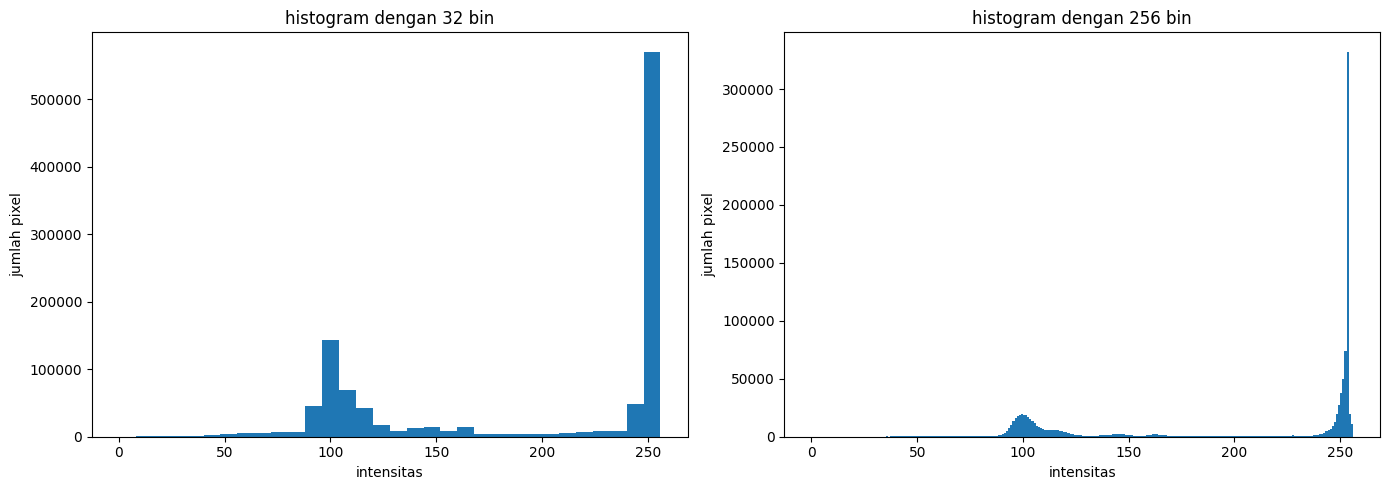

In [142]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# histogram PARAM['bins']
axs[0].bar(
    edges_param[:-1],
    hist_param,
    width=np.diff(edges_param),
    align='edge'
)

axs[0].set_title(
    'histogram dengan ' + str(PARAM['bins']) + ' bin'
)
axs[0].set_xlabel('intensitas')
axs[0].set_ylabel('jumlah pixel')


# histogram 256 bin
axs[1].bar(
    edges_256[:-1],
    hist_256,
    width=np.diff(edges_256),
    align='edge'
)

axs[1].set_title('histogram dengan 256 bin')
axs[1].set_xlabel('intensitas')
axs[1].set_ylabel('jumlah pixel')

plt.tight_layout()
plt.show()

ketika jumlah bin dikurangi menjadi 32 bin, beberapa nilai intensitas digabung dalam satu kelompok sehingga detail dan variasi kecil antar intensitas menjadi hilang. pada 256 bin, distribusi intensitas terlihat lebih rinci karena setiap tingkat intensitas direpresentasikan dengan lebih detail.

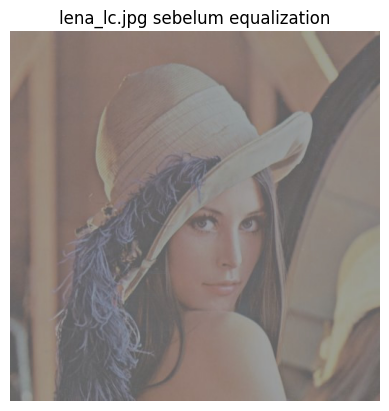

In [143]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena_lc.jpg')

# bgr menjadi rgb
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.imshow(img)
plt.title('lena_lc.jpg sebelum equalization')
plt.axis('off')
plt.show()

In [144]:
red = img[:, :, 0]
green = img[:, :, 1]
blue = img[:, :, 2]

In [145]:
def histogram_equalization(channel):

    # menghitung histogram
    hist, _ = np.histogram(
        channel.flatten(),
        bins=256,
        range=(0, 256)
    )

    # normalisasi histogram
    hist_normalized = hist / channel.size

    # menghitung cdf
    cdf = np.cumsum(hist_normalized)

    # membuat pemetaan intensitas baru
    mapping = np.round(255 * cdf).astype(np.uint8)

    # menerapkan mapping ke citra
    result = mapping[channel]

    return result

In [146]:
red_eq = histogram_equalization(red)
green_eq = histogram_equalization(green)
blue_eq = histogram_equalization(blue)

In [147]:
img_equalized = np.stack(
    (red_eq, green_eq, blue_eq),
    axis=2
)

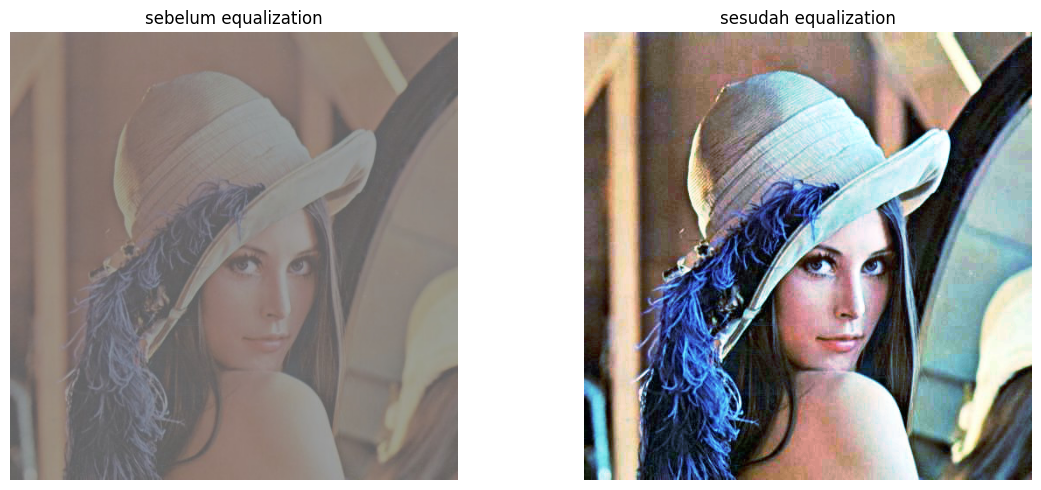

In [148]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(img)
axs[0].set_title('sebelum equalization')
axs[0].axis('off')

axs[1].imshow(img_equalized)
axs[1].set_title('sesudah equalization')
axs[1].axis('off')

plt.tight_layout()
plt.show()

In [149]:
names = np.arange(256)

hist_red_before, _ = np.histogram(
    img[:, :, 0].flatten(),
    bins=256,
    range=(0, 256)
)

hist_green_before, _ = np.histogram(
    img[:, :, 1].flatten(),
    bins=256,
    range=(0, 256)
)

hist_blue_before, _ = np.histogram(
    img[:, :, 2].flatten(),
    bins=256,
    range=(0, 256)
)

In [150]:
hist_red_after, _ = np.histogram(
    img_equalized[:, :, 0].flatten(),
    bins=256,
    range=(0, 256)
)

hist_green_after, _ = np.histogram(
    img_equalized[:, :, 1].flatten(),
    bins=256,
    range=(0, 256)
)

hist_blue_after, _ = np.histogram(
    img_equalized[:, :, 2].flatten(),
    bins=256,
    range=(0, 256)
)

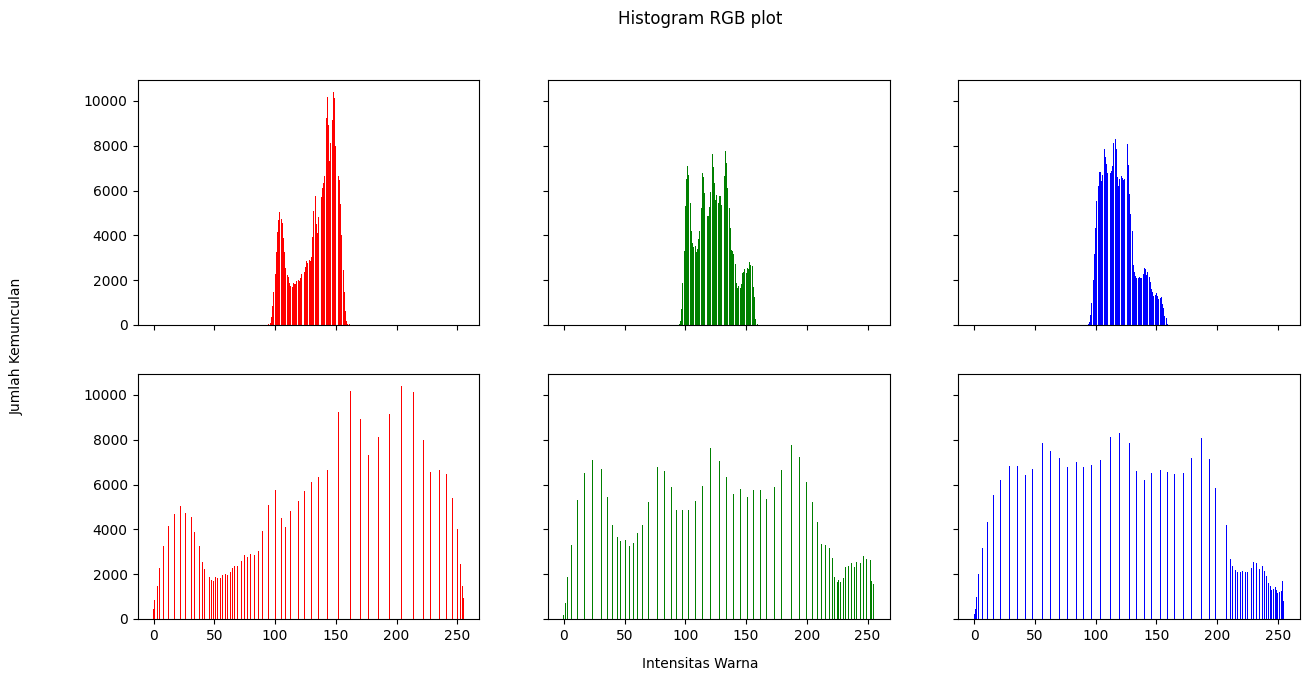

In [151]:
fig, axs = plt.subplots(
    2, 3,
    figsize=(15, 7),
    sharex=True,
    sharey=True
)

fig.suptitle('Histogram RGB plot')

# baris atas = sebelum equalization
axs[0, 0].bar(names, hist_red_before, color='red')
axs[0, 1].bar(names, hist_green_before, color='green')
axs[0, 2].bar(names, hist_blue_before, color='blue')

# baris bawah = sesudah equalization
axs[1, 0].bar(names, hist_red_after, color='red')
axs[1, 1].bar(names, hist_green_after, color='green')
axs[1, 2].bar(names, hist_blue_after, color='blue')

# label
fig.text(
    0.04, 0.5,
    'Jumlah Kemunculan',
    va='center',
    rotation='vertical'
)

fig.text(
    0.5, 0.04,
    'Intensitas Warna',
    ha='center'
)

plt.show()

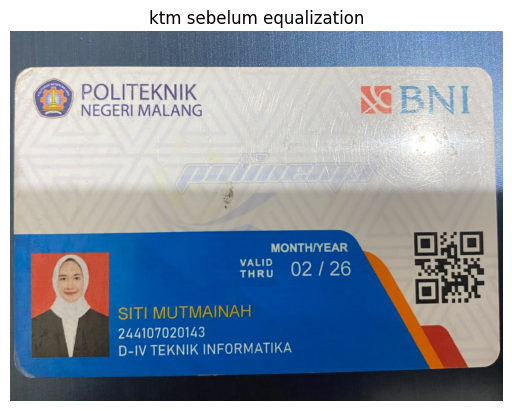

In [152]:
img = cv.imread('/content/KTM IIN3.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.imshow(img)
plt.title('ktm sebelum equalization')
plt.axis('off')
plt.show()

In [153]:
red = img[:, :, 0]
green = img[:, :, 1]
blue = img[:, :, 2]

In [154]:
def histogram_equalization(channel):
    hist, _ = np.histogram(
        channel.flatten(),
        bins=256,
        range=(0, 256)
    )

    hist_normalized = hist / channel.size
    cdf = np.cumsum(hist_normalized)

    mapping = np.round(255 * cdf).astype(np.uint8)
    result = mapping[channel]

    return result

In [155]:
red_eq = histogram_equalization(red)
green_eq = histogram_equalization(green)
blue_eq = histogram_equalization(blue)

img_equalized = np.stack(
    (red_eq, green_eq, blue_eq),
    axis=2
)

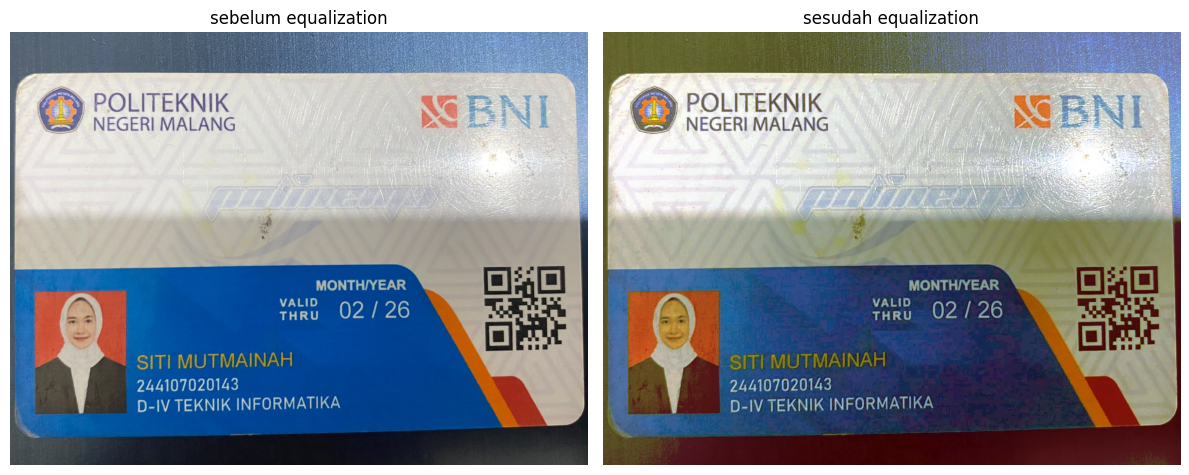

In [156]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(img)
axs[0].set_title('sebelum equalization')
axs[0].axis('off')

axs[1].imshow(img_equalized)
axs[1].set_title('sesudah equalization')
axs[1].axis('off')

plt.tight_layout()
plt.show()

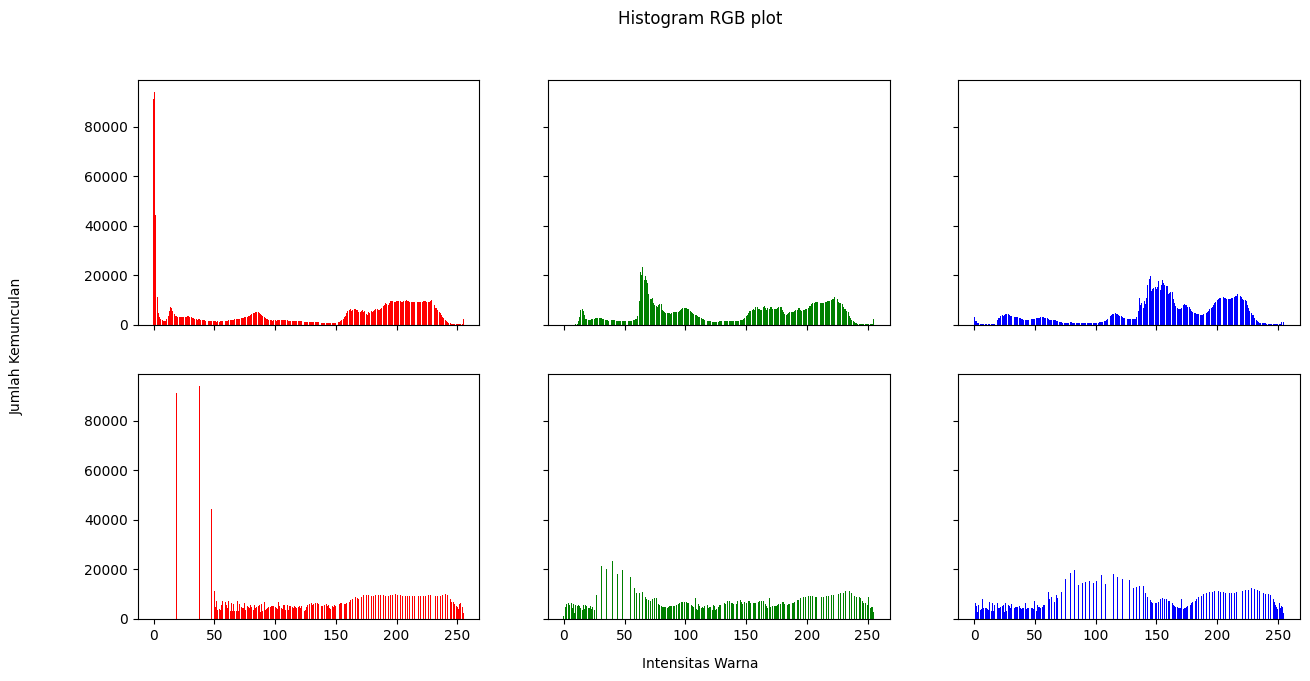

In [157]:
names = np.arange(256)

fig, axs = plt.subplots(
    2, 3,
    figsize=(15, 7),
    sharex=True,
    sharey=True
)

fig.suptitle('Histogram RGB plot')

# sebelum equalization
hist_red_before, _ = np.histogram(
    img[:, :, 0].flatten(), bins=256, range=(0, 256)
)

hist_green_before, _ = np.histogram(
    img[:, :, 1].flatten(), bins=256, range=(0, 256)
)

hist_blue_before, _ = np.histogram(
    img[:, :, 2].flatten(), bins=256, range=(0, 256)
)

axs[0, 0].bar(names, hist_red_before, color='red')
axs[0, 1].bar(names, hist_green_before, color='green')
axs[0, 2].bar(names, hist_blue_before, color='blue')


# sesudah equalization
hist_red_after, _ = np.histogram(
    img_equalized[:, :, 0].flatten(), bins=256, range=(0, 256)
)

hist_green_after, _ = np.histogram(
    img_equalized[:, :, 1].flatten(), bins=256, range=(0, 256)
)

hist_blue_after, _ = np.histogram(
    img_equalized[:, :, 2].flatten(), bins=256, range=(0, 256)
)

axs[1, 0].bar(names, hist_red_after, color='red')
axs[1, 1].bar(names, hist_green_after, color='green')
axs[1, 2].bar(names, hist_blue_after, color='blue')

fig.text(
    0.04, 0.5,
    'Jumlah Kemunculan',
    va='center',
    rotation='vertical'
)

fig.text(
    0.5, 0.04,
    'Intensitas Warna',
    ha='center'
)

plt.show()

In [158]:
image = cv.imread('/content/drive/MyDrive/PCVK/Images/lena_lc.jpg')

print(image is None)

False


In [159]:
b, g, r = cv.split(image)
b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)

image_cv = cv.merge(
    [b_equalized, g_equalized, r_equalized]
)

In [160]:
def equalization_manual(channel):

    hist, _ = np.histogram(
        channel.flatten(),
        bins=256,
        range=(0, 256)
    )

    hist_normalized = hist / channel.size

    cdf = np.cumsum(hist_normalized)

    mapping = np.round(
        255 * cdf
    ).astype(np.uint8)

    result = mapping[channel]

    return result

In [161]:
b_manual = equalization_manual(b)
g_manual = equalization_manual(g)
r_manual = equalization_manual(r)

image_manual = cv.merge(
    [b_manual, g_manual, r_manual]
)

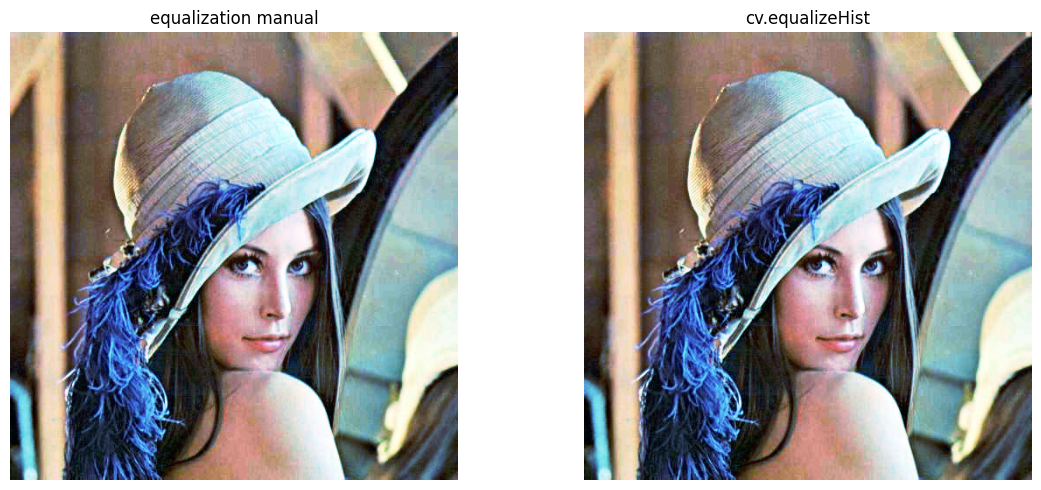

In [162]:
manual_rgb = cv.cvtColor(
    image_manual,
    cv.COLOR_BGR2RGB
)

cv_rgb = cv.cvtColor(
    image_cv,
    cv.COLOR_BGR2RGB
)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(manual_rgb)
axs[0].set_title('equalization manual')
axs[0].axis('off')

axs[1].imshow(cv_rgb)
axs[1].set_title('cv.equalizeHist')
axs[1].axis('off')

plt.tight_layout()
plt.show()

In [163]:
diff_b = np.max(
    np.abs(b_manual.astype(int) - b_equalized.astype(int))
)

diff_g = np.max(
    np.abs(g_manual.astype(int) - g_equalized.astype(int))
)

diff_r = np.max(
    np.abs(r_manual.astype(int) - r_equalized.astype(int))
)

print("selisih maksimum blue  :", diff_b)
print("selisih maksimum green :", diff_g)
print("selisih maksimum red   :", diff_r)

selisih maksimum blue  : 0
selisih maksimum green : 0
selisih maksimum red   : 0


hasil perbandingan menunjukkan selisih maksimum pada channel blue, green, dan red sebesar 0. hal ini menunjukkan bahwa hasil histogram equalization manual sama dengan hasil menggunakan fungsi cv.equalizehis pada citra lena_lc.jpg

In [164]:
image = cv.imread('/content/KTM IIN2.jpeg')

print(image is None)

False


In [165]:
b, g, r = cv.split(image)
b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)

image_cv = cv.merge(
    [b_equalized, g_equalized, r_equalized]
)

In [166]:
def equalization_manual(channel):

    hist, _ = np.histogram(
        channel.flatten(),
        bins=256,
        range=(0, 256)
    )

    hist_normalized = hist / channel.size

    cdf = np.cumsum(hist_normalized)

    mapping = np.round(
        255 * cdf
    ).astype(np.uint8)

    result = mapping[channel]

    return result

In [167]:
b_manual = equalization_manual(b)
g_manual = equalization_manual(g)
r_manual = equalization_manual(r)

image_manual = cv.merge(
    [b_manual, g_manual, r_manual]
)

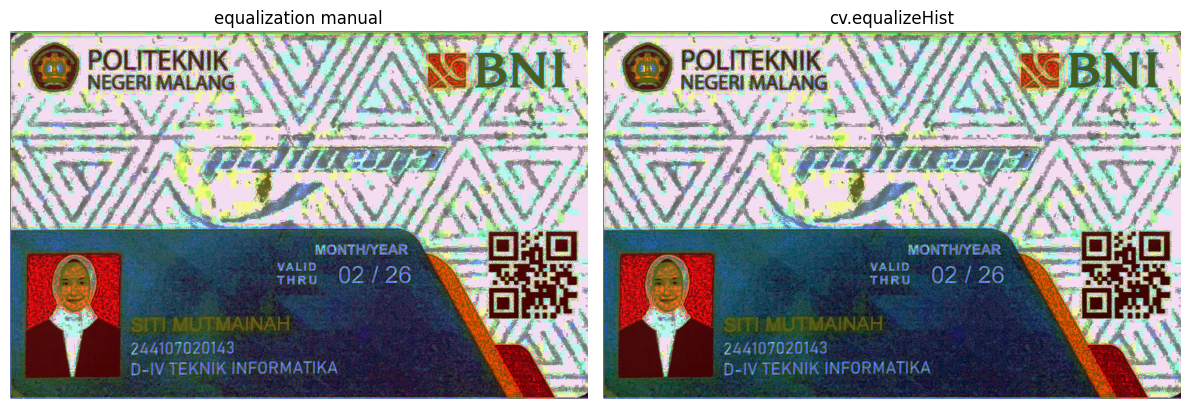

In [168]:
manual_rgb = cv.cvtColor(
    image_manual,
    cv.COLOR_BGR2RGB
)

cv_rgb = cv.cvtColor(
    image_cv,
    cv.COLOR_BGR2RGB
)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(manual_rgb)
axs[0].set_title('equalization manual')
axs[0].axis('off')

axs[1].imshow(cv_rgb)
axs[1].set_title('cv.equalizeHist')
axs[1].axis('off')

plt.tight_layout()
plt.show()

In [169]:
diff_b = np.max(
    np.abs(b_manual.astype(int) - b_equalized.astype(int))
)

diff_g = np.max(
    np.abs(g_manual.astype(int) - g_equalized.astype(int))
)

diff_r = np.max(
    np.abs(r_manual.astype(int) - r_equalized.astype(int))
)

print("selisih maksimum blue  :", diff_b)
print("selisih maksimum green :", diff_g)
print("selisih maksimum red   :", diff_r)

selisih maksimum blue  : 1
selisih maksimum green : 1
selisih maksimum red   : 11


pada citra ktm diperoleh selisih maksimum sebesar 1 pada channel blue, 1 pada channel green, dan 11 pada channel red. selisih terjadi karena terdapat perbedaan proses normalisasi cdf dan pembulatan nilai intensitas antara implementasi manual dengan fungsi cv.equalizehist.